# Stage 08: Exploratory Data Analysis

This notebook profiles and visualizes the canonical Stage 06 S&P 500 dataset, identifies data-quality and distributional risks, and translates the findings into testable feature hypotheses for later modeling.

## Scope, Assumptions, and Decision Context

- The analysis uses 19 January 2025 price observations and excludes the artificial first zero return from return-specific analysis, leaving 18 valid daily returns.
- Stage 06 cleaning and date ordering are assumed correct; this notebook verifies the resulting schema, missingness, and date gaps.
- The short period is adequate for demonstrating EDA but not for estimating stable seasonality, causal relationships, or trading performance.
- The EDA informs Stage 09 feature engineering and Stage 10b model validation. It does not itself authorize a trading decision.

In [1]:
import json
import os
from pathlib import Path
import sys

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

sns.set_theme(context='talk', style='whitegrid')
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'homework' / 'homework08').exists()
)
HOMEWORK_DIR = REPO_ROOT / 'homework' / 'homework08'
load_dotenv(HOMEWORK_DIR / '.env')
PROCESSED_DIR = HOMEWORK_DIR / os.environ.get('DATA_DIR_PROCESSED', 'data/processed')
REPORTS_DIR = HOMEWORK_DIR / os.environ.get('REPORTS_DIR', 'reports')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR))
from src.eda import correlation_matrix, eda_summary, strongest_pairwise_correlation

## 1. Load and Profile the Data

The notebook deliberately reads the stable Stage 06 artifact rather than choosing a timestamped file. The calls below show `.info()`, numeric summaries, missing counts, and counts plus proportions for every categorical column. Datetime fields are assessed separately as temporal variables.

In [2]:
source_path = (
    REPO_ROOT / 'homework' / 'homework06' / 'data' / 'processed'
    / 'sp500_prices_cleaned.parquet'
)
if not source_path.exists():
    raise FileNotFoundError('Run Stage 06 first to create sp500_prices_cleaned.parquet.')

prices = pd.read_parquet(source_path).sort_values('date').reset_index(drop=True)
prices.info()
display(prices.describe(include='all'))
display(prices.isna().sum().rename('missing_count').to_frame())

eda_data = prices.iloc[1:].copy().reset_index(drop=True)
analysis_columns = ['close', 'volume', 'daily_return', 'close_minmax', 'volume_zscore']
categorical_columns = prices.select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()
summary = eda_summary(eda_data, analysis_columns, categorical_columns)
display(summary['numeric_profile'])
display(pd.DataFrame(summary['attention_flags']).T)

for column, profile in summary['categorical_profile'].items():
    print(f'Categorical profile: {column}')
    display(profile)

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           19 non-null     datetime64[us]
 1   ticker         19 non-null     category      
 2   open           19 non-null     Float64       
 3   high           19 non-null     Float64       
 4   low            19 non-null     Float64       
 5   close          19 non-null     Float64       
 6   volume         19 non-null     Int64         
 7   daily_return   19 non-null     Float64       
 8   close_minmax   19 non-null     float64       
 9   volume_zscore  19 non-null     float64       
dtypes: Float64(5), Int64(1), category(1), datetime64[us](1), float64(2)
memory usage: 1.6 KB


,date,ticker,open,high,low,close,volume,daily_return,close_minmax,volume_zscore
count,19,19,19.0,19.0,19.0,19.0,19.0,19.0,19.000000,1.900000e+01
unique,NaN,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN
top,NaN,^GSPC,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN
freq,NaN,19,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN
mean,2025-01-16 18:56:50.526315,NaN,5979.073165,6006.28053,5945.102076,5981.357895,4399569210.526316,0.00157,0.529084,3.038505e-16
min,2025-01-02 00:00:00,NaN,5782.02002,5838.609863,5773.310059,5827.04,3621680000.0,-0.026559,0.000000,-2.320262e+00
25%,2025-01-09 00:00:00,NaN,5904.234863,5942.214844,5881.719971,5923.185,4268645000.0,-0.003767,0.329636,-3.905163e-01
50%,2025-01-16 00:00:00,NaN,5993.259766,6014.959961,5960.009766,5986.02,4436995000.0,0.001575,0.545068,1.116324e-01
75%,2025-01-23 12:00:00,NaN,6054.225098,6080.590088,6020.209961,6058.47,4589595000.0,0.007453,0.793465,5.668025e-01
max,2025-01-31 00:00:00,NaN,6121.430176,6128.180176,6088.740234,6118.71,4940120000.0,0.018313,1.000000,1.612337e+00


,missing_count
date,0
ticker,0
open,0
high,0
low,0
close,0
volume,0
daily_return,0
close_minmax,0
volume_zscore,0


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,18.0,5987.625,92.213124,5827.04,5938.6225,5991.34,6063.085,6118.71,-0.430716,-0.881185
volume,18.0,4442785277.777778,296731967.559913,3667340000.0,4333987500.0,4439367500.0,4612107500.0,4940120000.0,-0.758472,1.646916
daily_return,18.0,0.001657,0.010398,-0.026559,-0.004223,0.003425,0.008111,0.018313,-1.002176,2.005803
close_minmax,18.0,0.550571,0.316156,0.0,0.382564,0.563308,0.809288,1.0,-0.430716,-0.881185
volume_zscore,18.0,0.128903,0.885082,-2.184069,-0.195615,0.118709,0.633952,1.612337,-0.758472,1.646916


,missing_count,absolute_skew_over_1,iqr_outlier_count
close,0,False,0
volume,0,False,1
daily_return,0,True,1
close_minmax,0,False,0
volume_zscore,0,False,1


Categorical profile: ticker


,count,proportion
ticker,,
^GSPC,18,1.0


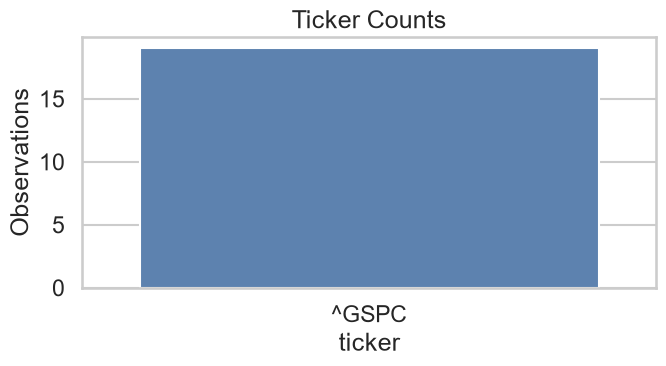

In [3]:
if categorical_columns:
    fig, axes = plt.subplots(1, len(categorical_columns), figsize=(7 * len(categorical_columns), 4))
    axes = [axes] if len(categorical_columns) == 1 else axes
    for axis, column in zip(axes, categorical_columns):
        sns.countplot(data=prices, x=column, ax=axis, color='#4f81bd')
        axis.set_title(f'{column.title()} Counts')
        axis.set_ylabel('Observations')
    plt.tight_layout()
    categorical_plot_path = REPORTS_DIR / 'eda_categorical_counts.png'
    plt.savefig(categorical_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
else:
    categorical_plot_path = None
    print('No categorical columns were detected; date is retained as a temporal field.')

**Profile interpretation.** All 19 rows represent the single ticker `^GSPC`, so ticker provides no cross-sectional variation. There are no missing values after Stage 06 processing. The date column is a time index, not a nominal category; its spacing is checked in the time-series section.

## 2. Univariate Distributions

Histograms and boxplots cover three key variables: daily return, trading volume, and closing level. Together they show location, spread, skewness, and possible extreme observations.

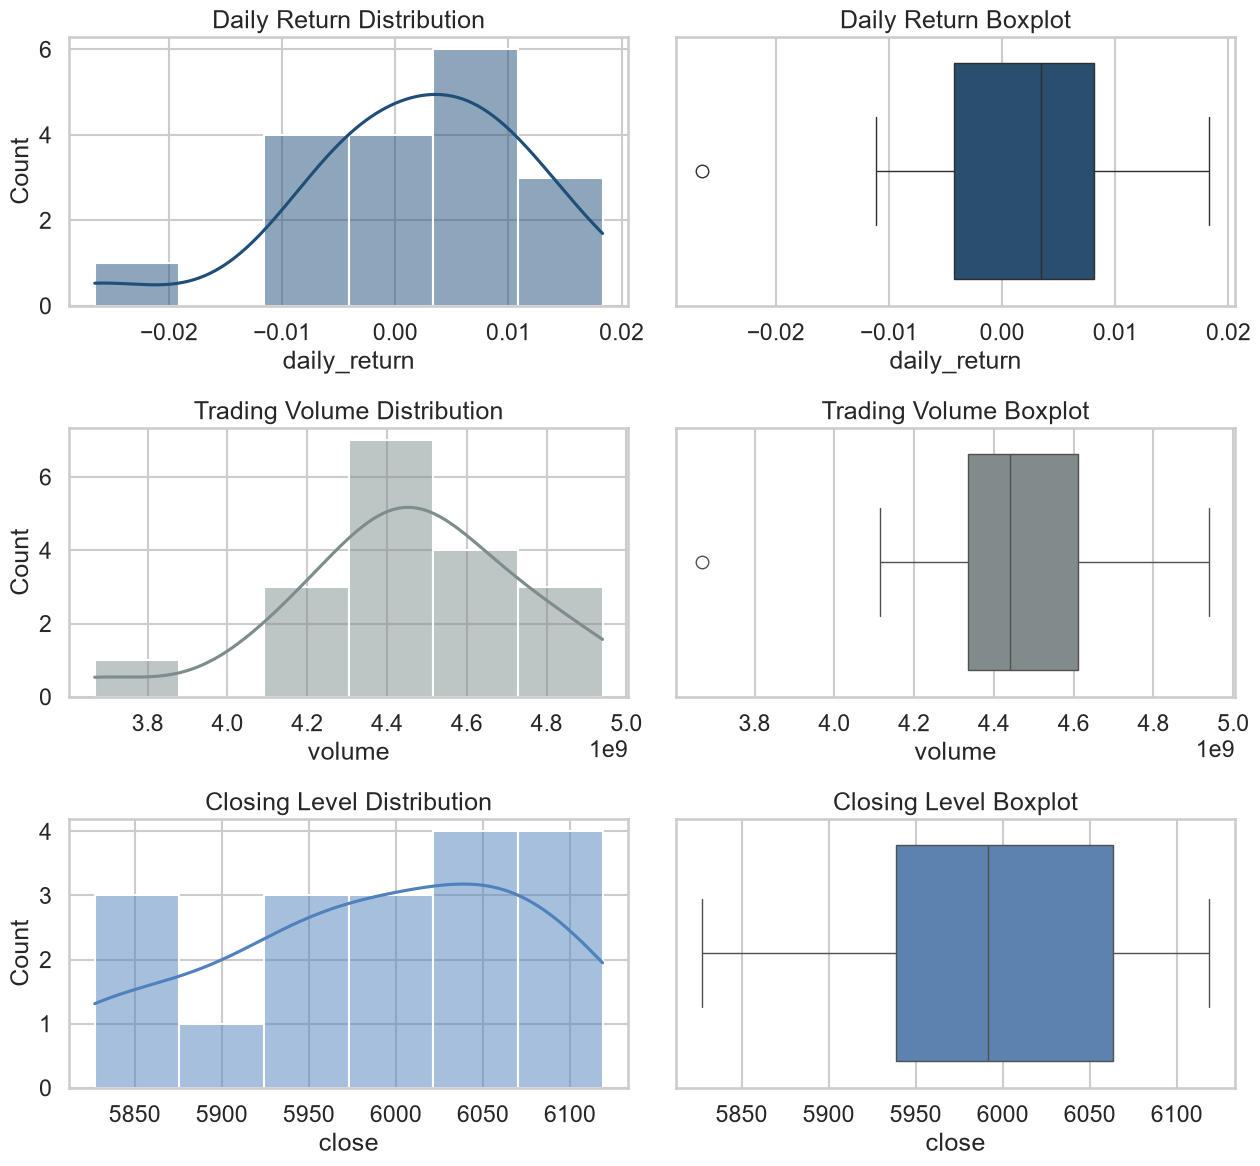

In [4]:
distribution_specs = [
    ('daily_return', 'Daily Return', '#1f4e79'),
    ('volume', 'Trading Volume', '#7f8c8d'),
    ('close', 'Closing Level', '#4f81bd'),
]
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
for row, (column, label, color) in enumerate(distribution_specs):
    sns.histplot(eda_data[column], kde=True, ax=axes[row, 0], color=color)
    axes[row, 0].set_title(f'{label} Distribution')
    sns.boxplot(x=eda_data[column], ax=axes[row, 1], color=color)
    axes[row, 1].set_title(f'{label} Boxplot')
plt.tight_layout()
distribution_plot_path = REPORTS_DIR / 'eda_distributions.png'
plt.savefig(distribution_plot_path, dpi=150, bbox_inches='tight')
plt.show()

**Distribution interpretation.** Daily returns are moderately left-skewed (about -1.00), driven partly by the -2.66% move on January 10. This downside observation is economically important even if a mechanical rule does not remove it. Volume and closing level should be scaled before models that are sensitive to feature magnitude.

## 3. Bivariate Relationships and Correlations

Two scatterplots test whether standardized volume is associated with signed or absolute daily movement. The heatmap is a compact supplement; all correlations remain descriptive because the sample is very small.

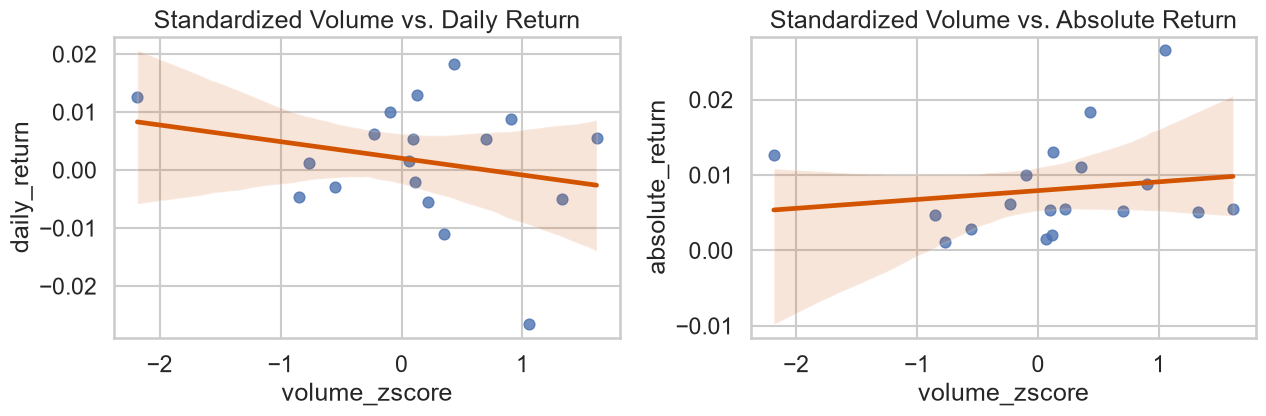

,close,volume,daily_return
close,1.000000,0.033515,0.281693
volume,0.033515,1.000000,-0.244651
daily_return,0.281693,-0.244651,1.000000


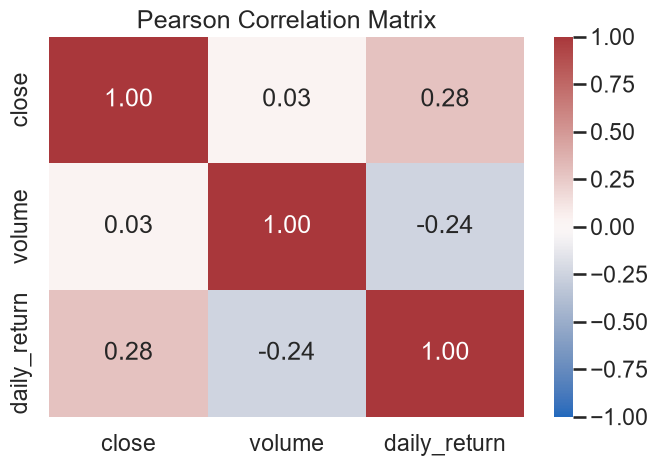

In [5]:
eda_data['absolute_return'] = eda_data['daily_return'].abs()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.regplot(
    data=eda_data, x='volume_zscore', y='daily_return', ax=axes[0],
    scatter_kws={'s': 60}, line_kws={'color': '#d35400'}
)
axes[0].set_title('Standardized Volume vs. Daily Return')
sns.regplot(
    data=eda_data, x='volume_zscore', y='absolute_return', ax=axes[1],
    scatter_kws={'s': 60}, line_kws={'color': '#d35400'}
)
axes[1].set_title('Standardized Volume vs. Absolute Return')
plt.tight_layout()
relationship_plot_path = REPORTS_DIR / 'eda_relationships.png'
plt.savefig(relationship_plot_path, dpi=150, bbox_inches='tight')
plt.show()

correlation_columns = ['close', 'volume', 'daily_return']
correlation = correlation_matrix(eda_data, correlation_columns)
display(correlation)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
correlation_plot_path = REPORTS_DIR / 'eda_correlation_matrix.png'
plt.savefig(correlation_plot_path, dpi=150, bbox_inches='tight')
plt.show()

**Relationship interpretation.** The strongest displayed non-duplicate Pearson correlation is only about 0.28 (close versus daily return). The volume relationships are also weak and their confidence bands are wide. These results do not justify treating volume or price level as reliable standalone predictors; later models should test lagged and rolling features out of sample.

## 4. Time-Series Structure

The series is sorted before plotting. Calendar gaps greater than one day are listed explicitly; weekend and market-holiday gaps should not be mistaken for missing trading records.

,date,calendar_gap_days
0,2025-01-06,3.0
1,2025-01-10,2.0
2,2025-01-13,3.0
3,2025-01-21,4.0
4,2025-01-28,4.0


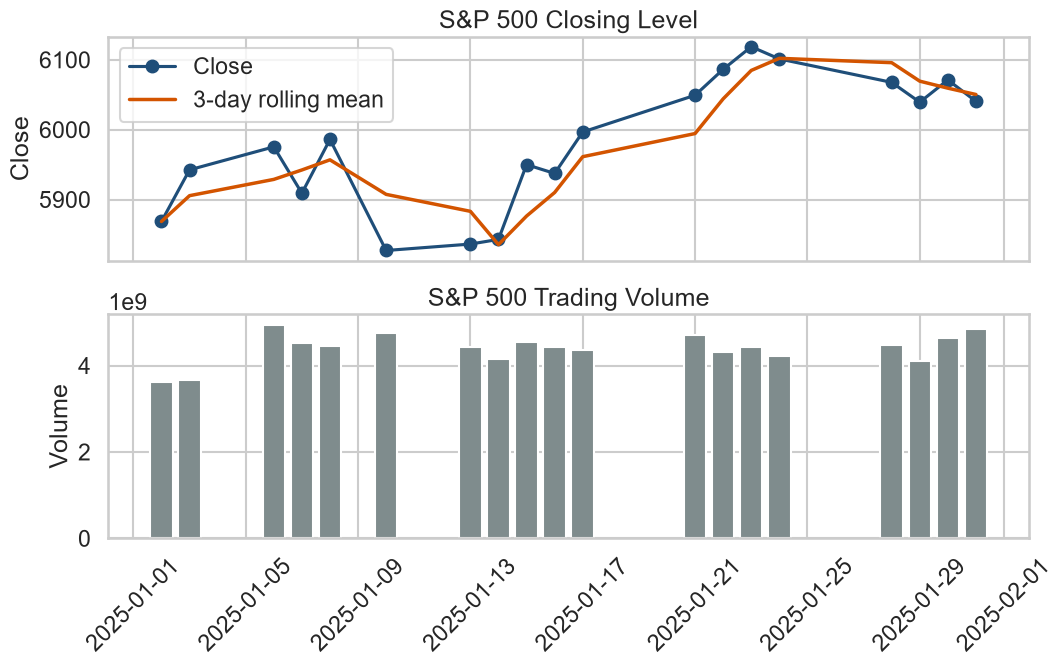

In [6]:
prices_for_time = prices.sort_values('date').copy()
prices_for_time['calendar_gap_days'] = prices_for_time['date'].diff().dt.days
prices_for_time['close_3day_mean'] = prices_for_time['close'].rolling(3, min_periods=1).mean()
display(
    prices_for_time.loc[
        prices_for_time['calendar_gap_days'].gt(1), ['date', 'calendar_gap_days']
    ].reset_index(drop=True)
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(
    prices_for_time['date'], prices_for_time['close'], marker='o',
    label='Close', color='#1f4e79'
)
axes[0].plot(
    prices_for_time['date'], prices_for_time['close_3day_mean'], linewidth=2.5,
    label='3-day rolling mean', color='#d35400'
)
axes[0].set_title('S&P 500 Closing Level')
axes[0].set_ylabel('Close')
axes[0].legend()
axes[1].bar(prices_for_time['date'], prices_for_time['volume'], color='#7f8c8d', width=0.8)
axes[1].set_title('S&P 500 Trading Volume')
axes[1].set_ylabel('Volume')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
time_series_plot_path = REPORTS_DIR / 'eda_time_series.png'
plt.savefig(time_series_plot_path, dpi=150, bbox_inches='tight')
plt.show()

**Time-series interpretation.** The closing level rises 2.93% from January 2 to January 31, with a local peak on January 23 and a mild pullback afterward. This is a short-run upward level movement, not evidence of a persistent trend. One month cannot support a seasonality claim, and no durable level shift is identifiable. The two- to four-day calendar gaps align with non-trading days. Stage 09 should construct lagged returns, rolling volatility, and volume-relative features without future leakage; Stage 10b should use chronological splits rather than random train/test shuffling.

## 5. Save Reproducible Outputs

Stable filenames are overwritten on each run. This avoids selecting stale timestamped artifacts and makes the source-to-output lineage unambiguous.

In [7]:
profile_path = PROCESSED_DIR / 'numeric_profile.csv'
categorical_profile_path = PROCESSED_DIR / 'categorical_profile.csv'
correlation_path = PROCESSED_DIR / 'correlation_matrix.csv'
summary_path = PROCESSED_DIR / 'eda_summary.json'
summary['numeric_profile'].to_csv(profile_path)
correlation.to_csv(correlation_path)

categorical_rows = []
for variable, profile in summary['categorical_profile'].items():
    for value, row in profile.iterrows():
        categorical_rows.append({
            'variable': variable,
            'value': str(value),
            'count': int(row['count']),
            'proportion': float(row['proportion']),
        })
pd.DataFrame(
    categorical_rows,
    columns=['variable', 'value', 'count', 'proportion'],
).to_csv(categorical_profile_path, index=False)

strongest_left, strongest_right, strongest_value = strongest_pairwise_correlation(correlation)
largest_move = eda_data.loc[eda_data['absolute_return'].idxmax()]
period_return = prices.iloc[-1]['close'] / prices.iloc[0]['close'] - 1
summary_json = {
    'source_file': source_path.relative_to(REPO_ROOT).as_posix(),
    'price_observations': int(len(prices)),
    'return_observations': int(len(eda_data)),
    'missing_values': {key: int(value) for key, value in summary['missing'].items()},
    'period_return': float(period_return),
    'largest_absolute_return': {
        'date': str(largest_move['date'].date()),
        'daily_return': float(largest_move['daily_return']),
    },
    'strongest_pairwise_correlation': {
        'variables': [strongest_left, strongest_right],
        'value': strongest_value,
    },
    'attention_flags': summary['attention_flags'],
    'outputs': {
        'numeric_profile': profile_path.relative_to(REPO_ROOT).as_posix(),
        'categorical_profile': categorical_profile_path.relative_to(REPO_ROOT).as_posix(),
        'correlation': correlation_path.relative_to(REPO_ROOT).as_posix(),
        'categorical_plot': categorical_plot_path.relative_to(REPO_ROOT).as_posix(),
        'distribution_plot': distribution_plot_path.relative_to(REPO_ROOT).as_posix(),
        'relationship_plot': relationship_plot_path.relative_to(REPO_ROOT).as_posix(),
        'correlation_plot': correlation_plot_path.relative_to(REPO_ROOT).as_posix(),
        'time_series_plot': time_series_plot_path.relative_to(REPO_ROOT).as_posix(),
    },
}
summary_path.write_text(json.dumps(summary_json, indent=2), encoding='utf-8')

insights = f'''# Stage 08 EDA Insights

## Top 3 Insights
1. The index rose {period_return:.2%} over the observed month, but 19 prices are insufficient to establish a persistent trend or seasonality.
2. The largest daily move was {largest_move['daily_return']:.2%} on {largest_move['date'].date()}, and return skewness is {eda_data['daily_return'].skew():.2f}; later diagnostics should retain visibility of downside tail behavior.
3. The strongest displayed correlation is `{strongest_left}` versus `{strongest_right}` ({strongest_value:.2f}), which is too weak and sample-dependent to support a causal or predictive claim.

## Assumptions & Risks
- Stage 06 schema, cleaning, and trading-date coverage are assumed correct.
- The single-ticker, one-month sample excludes other assets and market regimes.
- Calendar gaps reflect non-trading days; they are not filled as if prices were observed.
- Correlation is descriptive and may be unstable in a larger or later sample.

## Implications for Next Step
- Stage 09: create lagged returns, rolling volatility, and volume-relative features using only past data.
- Stage 10b: preserve chronological order, compare against simple baselines, and evaluate performance on later unseen periods.
'''
insights_path = REPORTS_DIR / 'eda_insights.md'
insights_path.write_text(insights, encoding='utf-8')

assert profile_path.exists() and categorical_profile_path.exists()
assert pd.read_csv(profile_path, index_col=0).shape[0] == len(analysis_columns)
assert pd.read_csv(correlation_path, index_col=0).shape == (3, 3)
assert summary_path.exists() and insights_path.exists()
print('Saved stable EDA outputs successfully.')

Saved stable EDA outputs successfully.


## Final Conclusions

### Top 3 Insights

1. The S&P 500 closing level increased 2.93% across the observed January window, but the sample is too short to establish a durable trend or seasonality.
2. Returns are left-skewed (approximately -1.00), and the largest daily move is -2.66% on January 10. Downside-tail behavior should remain visible in later model diagnostics rather than being automatically removed.
3. The strongest displayed pairwise correlation is modest (approximately 0.28). Current relationships are descriptive and do not establish causality or reliable predictive value.

### Assumptions & Risks

- Stage 06 cleaning, schema validation, and trading-date coverage are assumed correct.
- One ticker and one month do not represent different assets, volatility regimes, or market cycles.
- Non-trading-day calendar gaps are expected; treating them as observed zero-return days would distort the series.
- Multiple exploratory comparisons can produce unstable patterns in a sample of only 18 returns.

### Implications for the Next Step

- **Stage 09:** engineer lagged returns, rolling volatility, and volume-relative features using past information only; document warm-up rows created by rolling windows.
- **Stage 10b:** use chronological validation, compare against simple baselines, and evaluate on a longer unseen period. Do not rely on random splits or the weak in-sample correlations shown here.